In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import pickle
from scipy import integrate
from scipy.optimize import curve_fit
from scipy.stats import spearmanr, kendalltau, norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, DotProduct, WhiteKernel
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
np.random.seed(42)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'DejaVu Sans'
})

print('✓ All libraries loaded successfully')
print(f'  NumPy    {np.__version__}')
print(f'  Pandas   {pd.__version__}')
import sklearn; print(f'  Sklearn  {sklearn.__version__}')

✓ All libraries loaded successfully
  NumPy    1.26.4
  Pandas   2.2.2
  Sklearn  1.5.1


In [2]:
EXCEL_PATH = "residual_stress_maraging_steel_dataset.xlsx"

In [3]:
# ── Load & Clean Dataset ──
df_raw = pd.read_excel(EXCEL_PATH, sheet_name='Sheet1')  # or correct name

df = df_raw[[
    'LP',
    'SS',
    'HS',
    'ED',
    'Stress z=3.861'
]].copy()

df.columns = ['Power_W', 'Speed_mms', 'Hatch_mm','ED_Jmm3', 'Res_Stress']
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print('=' * 50)
print('  MS300 RESIDUAL STRESSES DATASET')
print('=' * 50)
print(f'  Rows              : {len(df)}')
print(f'  Columns           : {list(df.columns)}')
print(f'  Stress range     : {df.Res_Stress.min():.2f}% → {df.Res_Stress.max():.2f}%')
print(f'  Power range       : {df.Power_W.min():.0f} → {df.Power_W.max():.0f} W')
print(f'  Speed range       : {df.Speed_mms.min():.0f} → {df.Speed_mms.max():.0f} mm/s')
print(f'  Hatch spacing     : {df.Hatch_mm.min():.2f} → {df.Hatch_mm.max():.2f} mm')
print(f'  VED range         : {df.ED_Jmm3.min():.1f} → {df.ED_Jmm3.max():.1f} J/mm³')
print()
display(df.describe().round(3))

  MS300 RESIDUAL STRESSES DATASET
  Rows              : 44
  Columns           : ['Power_W', 'Speed_mms', 'Hatch_mm', 'ED_Jmm3', 'Res_Stress']
  Stress range     : -461.82% → -323.64%
  Power range       : 150 → 350 W
  Speed range       : 850 → 1050 mm/s
  Hatch spacing     : 0.08 → 0.12 mm
  VED range         : 37.5 → 92.6 J/mm³



,Power_W,Speed_mms,Hatch_mm,ED_Jmm3,Res_Stress
count,44.00,44.000,44.000,44.000,44.000
mean,250.00,961.364,0.101,64.763,-388.639
std,58.07,62.751,0.012,14.067,36.022
min,150.00,850.000,0.080,37.500,-461.820
25%,237.50,937.500,0.098,54.825,-409.718
50%,250.00,950.000,0.100,65.789,-373.356
75%,262.50,1000.000,0.110,74.554,-362.353
max,350.00,1050.000,0.120,92.593,-323.636


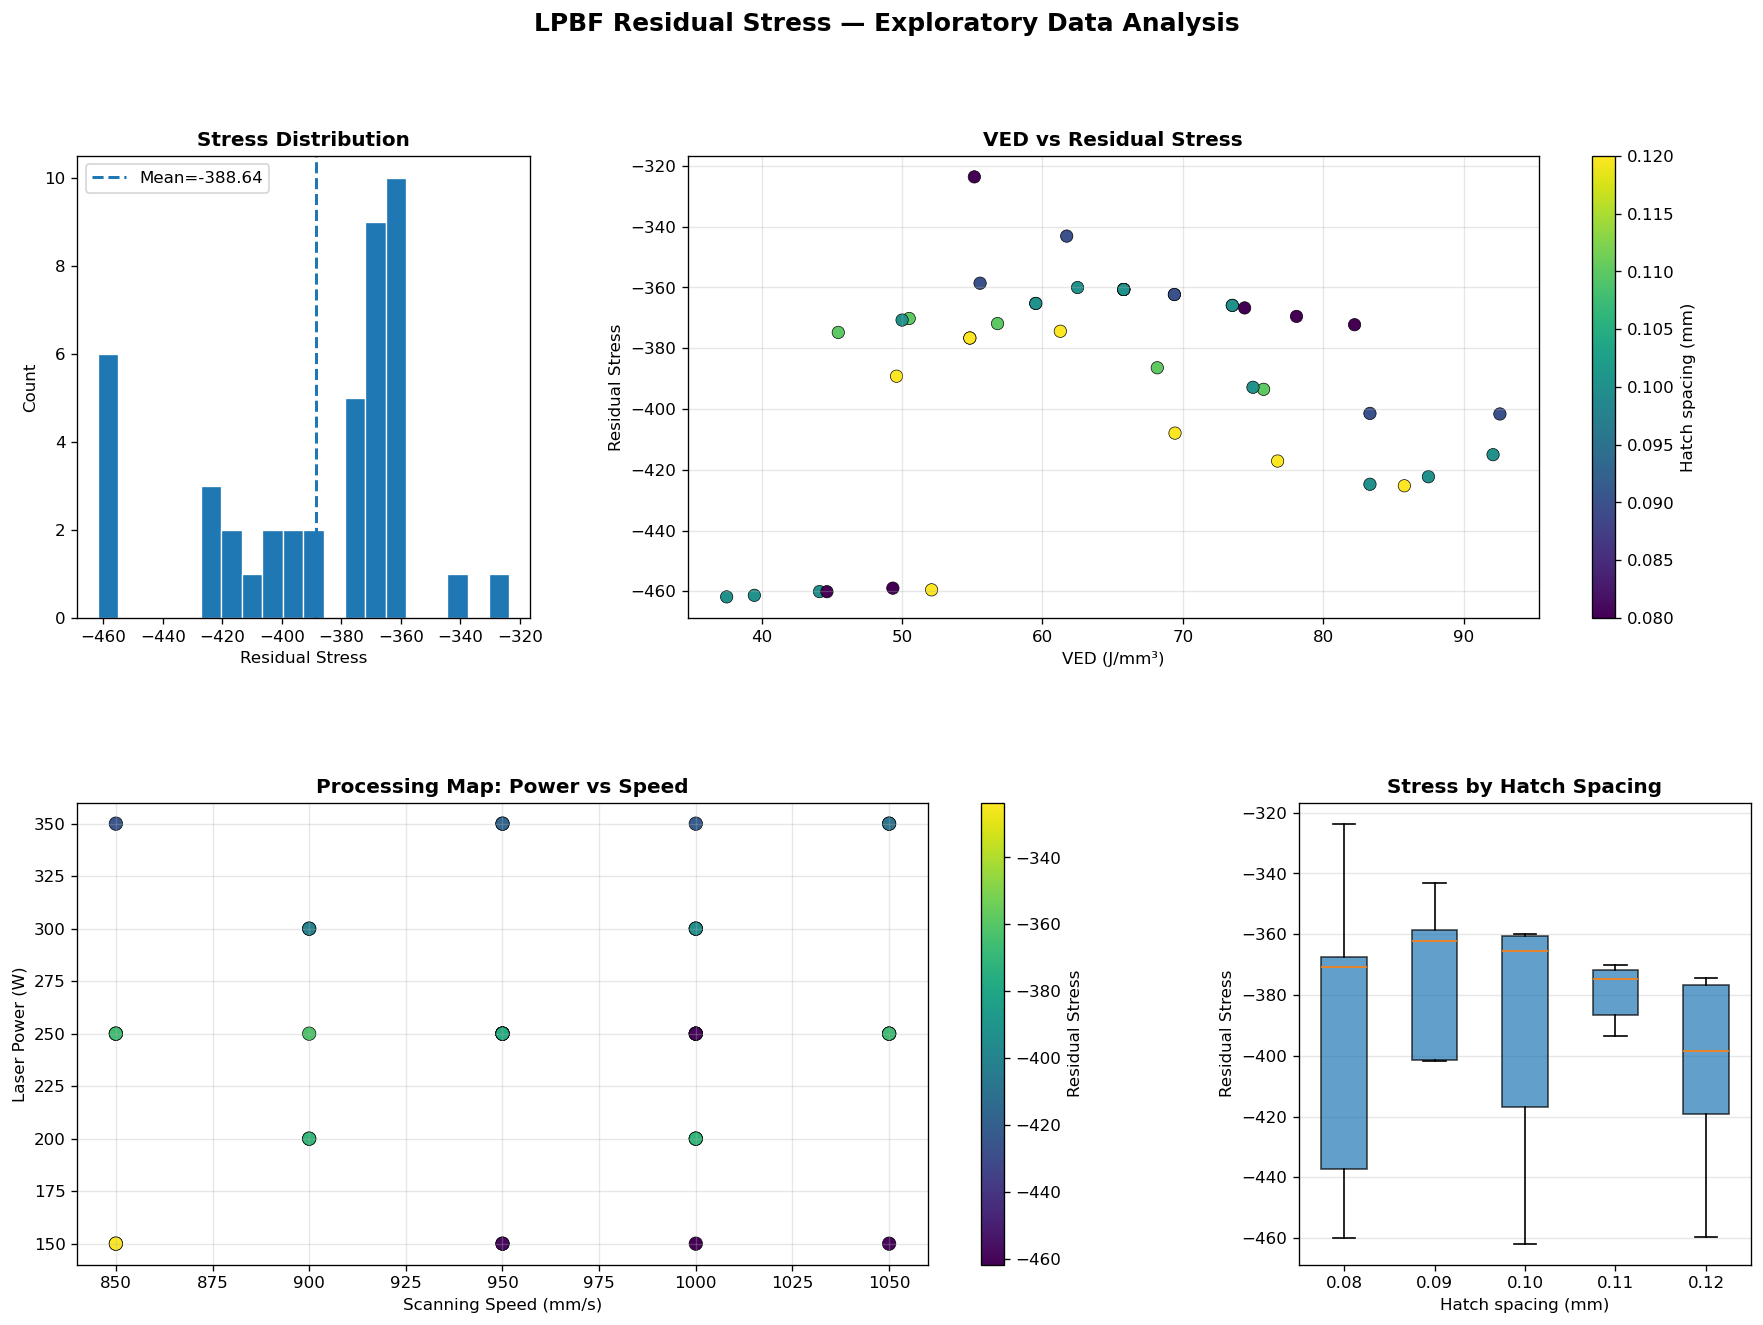

✓ EDA plot saved


In [4]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('LPBF Residual Stress — Exploratory Data Analysis', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1: Stress distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['Res_Stress'], bins=20, edgecolor='white', linewidth=0.8)
ax1.axvline(df['Res_Stress'].mean(), linestyle='--', linewidth=1.8,
            label=f"Mean={df['Res_Stress'].mean():.2f}")
ax1.set_xlabel('Residual Stress'); ax1.set_ylabel('Count')
ax1.set_title('Stress Distribution', fontweight='bold'); ax1.legend()

# 2: VED vs Stress
ax2 = fig.add_subplot(gs[0, 1:])
sc = ax2.scatter(df['ED_Jmm3'], df['Res_Stress'],
                 c=df['Hatch_mm'], s=55, edgecolors='k', linewidths=0.4)
plt.colorbar(sc, ax=ax2, label='Hatch spacing (mm)')
ax2.set_xlabel('VED (J/mm³)'); ax2.set_ylabel('Residual Stress')
ax2.set_title('VED vs Residual Stress', fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3: Processing map (Power vs Speed colored by stress)
ax3 = fig.add_subplot(gs[1, :2])
sc2 = ax3.scatter(df['Speed_mms'], df['Power_W'], c=df['Res_Stress'],
                  s=65, edgecolors='k', linewidths=0.4)
cb = plt.colorbar(sc2, ax=ax3); cb.set_label('Residual Stress')
ax3.set_xlabel('Scanning Speed (mm/s)'); ax3.set_ylabel('Laser Power (W)')
ax3.set_title('Processing Map: Power vs Speed', fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4: Box plot by hatch spacing
ax4 = fig.add_subplot(gs[1, 2])
hs_vals = sorted(df['Hatch_mm'].unique())
groups  = [df[df['Hatch_mm'] == hs]['Res_Stress'].values for hs in hs_vals]

bp = ax4.boxplot(groups, patch_artist=True,
                 labels=[f'{hs:.2f}' for hs in hs_vals])

for patch in bp['boxes']:
    patch.set_alpha(0.7)

ax4.set_xlabel('Hatch spacing (mm)')
ax4.set_ylabel('Residual Stress')
ax4.set_title('Stress by Hatch Spacing', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.savefig('EDA.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('✓ EDA plot saved')

In [5]:
class MS300Props:
    # Temperatures
    T_liquidus   = 1410.0    # °C (approx range 1400–1420°C)
    T_preheat    = 100.0     # °C (same as before unless changed)
    delta_T      = T_liquidus - T_preheat

    # Thermal properties
    k            = 25.0      # W/m·K (higher than Haynes 282)
    rho          = 8000.0    # kg/m³
    cp           = 460.0     # J/kg·K

    # Derived property
    alpha        = k / (rho * cp)   # m²/s thermal diffusivity

    # Laser/material interaction
    absorptivity = 0.40      # slightly higher than Ni-based alloys

    # Laser beam
    beam_radius  = 35e-6     # m (same 70 µm diameter)

props = MS300Props()

In [6]:
import numpy as np
from scipy import integrate

# ── Eagar-Tsai Temperature Field ──
def et_temperature(xi, y, z, power_W, speed_mms, props):
    """
    Temperature rise at (xi, y, z) using Eagar-Tsai model.
    Inputs match dataset: Power_W, Speed_mms
    """
    v = speed_mms / 1000.0  # mm/s → m/s

    eta   = props.absorptivity
    alpha = props.alpha
    k     = props.k
    r     = props.beam_radius

    prefactor = (np.sqrt(2) * eta * power_W * alpha) / (np.pi**1.5 * k)

    def integrand(tau):
        if tau <= 0:
            return 0.0

        dxy = 2 * alpha * tau + r**2
        dz  = 4 * alpha * tau

        if dxy <= 0 or dz <= 0:
            return 0.0

        exponent = (
            -(xi**2)/(2*dxy)
            -(y**2)/(2*dxy)
            -(z**2)/dz
            -(v * xi)/(2 * alpha)
            -(v**2 * tau)/(4 * alpha)
        )

        denom = dxy * np.sqrt(2 * alpha * tau)

        return np.exp(exponent) / denom if denom > 0 else 0.0

    # Integration limits slightly improved for stability
    result, _ = integrate.quad(
        integrand,
        1e-9, 5e-3,   # extended upper bound → better melt pool capture
        limit=200,
        epsabs=1e-8,
        epsrel=1e-6
    )

    return prefactor * result


# ── Melt Pool Geometry ──
def et_melt_pool(power_W, speed_mms, props):
    """
    Returns melt pool width & depth (µm)
    """
    target = props.delta_T

    # Check melting
    if et_temperature(0, 0, 0, power_W, speed_mms, props) < target:
        return 0.0, 0.0

    # ---- WIDTH ----
    y_lo, y_hi = 0.0, 1.5e-3  # tighter bounds (realistic LPBF ~ 50–300 µm)

    for _ in range(50):
        y_mid = (y_lo + y_hi) / 2
        T = et_temperature(0, y_mid, 0, power_W, speed_mms, props)

        if T > target:
            y_lo = y_mid
        else:
            y_hi = y_mid

    width_um = 2 * ((y_lo + y_hi) / 2) * 1e6

    # ---- DEPTH ----
    z_lo, z_hi = 0.0, 1.5e-3

    for _ in range(50):
        z_mid = (z_lo + z_hi) / 2
        T = et_temperature(0, 0, z_mid, power_W, speed_mms, props)

        if T > target:
            z_lo = z_mid
        else:
            z_hi = z_mid

    depth_um = ((z_lo + z_hi) / 2) * 1e6

    return width_um, depth_um


# ── Apply to your dataset ──
def compute_melt_pool_for_df(df, props):
    widths = []
    depths = []

    for _, row in df.iterrows():
        w, d = et_melt_pool(row['Power_W'], row['Speed_mms'], props)
        widths.append(w)
        depths.append(d)

    df['MP_Width_um'] = widths
    df['MP_Depth_um'] = depths

    return df


print("✓ ET model ready for MS300 dataset")

# Test
w, d = et_melt_pool(300, 1000, props)
print(f"Test → P=300W, v=1000 mm/s → Width={w:.1f} µm, Depth={d:.1f} µm")

✓ ET model ready for MS300 dataset
Test → P=300W, v=1000 mm/s → Width=164.0 µm, Depth=29.9 µm


In [7]:
# ── Apply ET Model to Dataset ──

n = len(df)
print(f'Computing ET predictions for {n} data points...')
print('(Numerical integration per point — may take some time)\n')

widths = []
depths = []

for i, row in df.iterrows():
    w, d = et_melt_pool(row['Power_W'], row['Speed_mms'], props)

    widths.append(w)
    depths.append(d)

    # Progress update every 10 points (better for small dataset)
    if (i + 1) % 10 == 0 or (i + 1) == n:
        print(f'  {i+1}/{n} complete...')

# Store results
df['ET_Width_um'] = widths
df['ET_Depth_um'] = depths

# Width/Depth ratio (safe division)
df['ET_WD_ratio'] = np.where(
    df['ET_Depth_um'] > 0,
    df['ET_Width_um'] / df['ET_Depth_um'],
    np.nan
)

# Summary
print('\n✓ ET predictions complete!')

print(f"  Width  : {df['ET_Width_um'].min():.1f} → {df['ET_Width_um'].max():.1f} µm")
print(f"  Depth  : {df['ET_Depth_um'].min():.1f} → {df['ET_Depth_um'].max():.1f} µm")
print(f"  W/D    : {df['ET_WD_ratio'].min():.2f} → {df['ET_WD_ratio'].max():.2f}")

Computing ET predictions for 44 data points...
(Numerical integration per point — may take some time)

  10/44 complete...
  20/44 complete...
  30/44 complete...
  40/44 complete...
  44/44 complete...

✓ ET predictions complete!
  Width  : 136.1 → 176.7 µm
  Depth  : 20.0 → 38.3 µm
  W/D    : 4.62 → 6.79


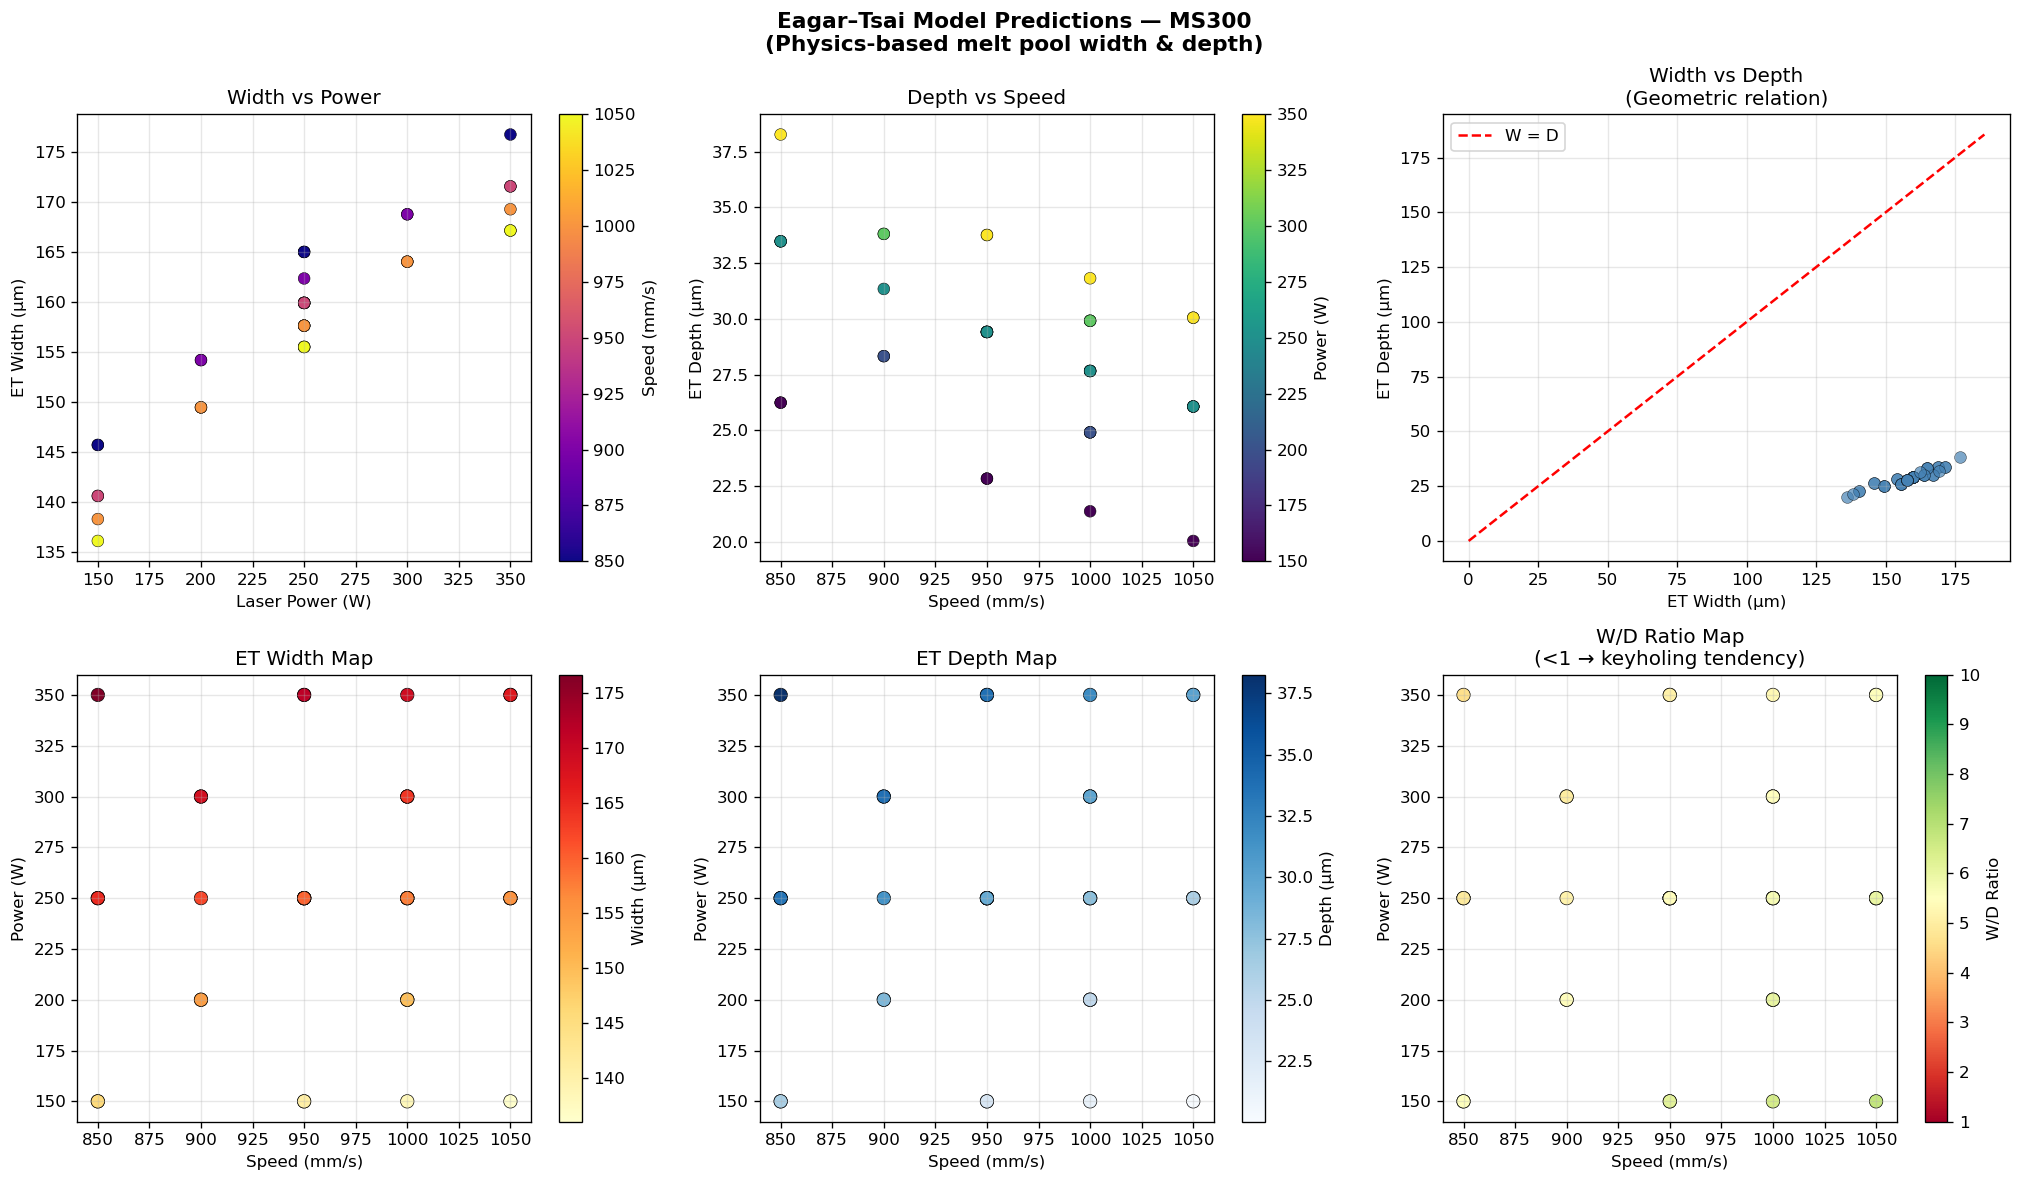

✓ ET visualization saved as ET_Model_MS300.png


In [8]:
# ── Visualize ET Predictions (MS300 Dataset) ──

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    'Eagar–Tsai Model Predictions — MS300\n'
    '(Physics-based melt pool width & depth)',
    fontsize=13, fontweight='bold'
)

# Filter only valid melt pool results
df_m = df[(df['ET_Width_um'] > 0) & (df['ET_Depth_um'] > 0)]

# ---- 1: Width vs Power ----
sc = axes[0,0].scatter(
    df_m['Power_W'], df_m['ET_Width_um'],
    c=df_m['Speed_mms'], cmap='plasma',
    s=50, edgecolors='k', linewidths=0.3
)
plt.colorbar(sc, ax=axes[0,0], label='Speed (mm/s)')
axes[0,0].set(
    xlabel='Laser Power (W)',
    ylabel='ET Width (µm)',
    title='Width vs Power'
)
axes[0,0].grid(alpha=0.3)

# ---- 2: Depth vs Speed ----
sc = axes[0,1].scatter(
    df_m['Speed_mms'], df_m['ET_Depth_um'],
    c=df_m['Power_W'], cmap='viridis',
    s=50, edgecolors='k', linewidths=0.3
)
plt.colorbar(sc, ax=axes[0,1], label='Power (W)')
axes[0,1].set(
    xlabel='Speed (mm/s)',
    ylabel='ET Depth (µm)',
    title='Depth vs Speed'
)
axes[0,1].grid(alpha=0.3)

# ---- 3: Width vs Depth ----
axes[0,2].scatter(
    df_m['ET_Width_um'], df_m['ET_Depth_um'],
    c='steelblue', alpha=0.7,
    edgecolors='k', linewidths=0.3, s=50
)

# Safe limit calculation
lim = max(
    df_m['ET_Width_um'].max(),
    df_m['ET_Depth_um'].max()
) * 1.05

axes[0,2].plot([0, lim], [0, lim], 'r--', lw=1.5, label='W = D')
axes[0,2].set(
    xlabel='ET Width (µm)',
    ylabel='ET Depth (µm)',
    title='Width vs Depth\n(Geometric relation)'
)
axes[0,2].legend()
axes[0,2].grid(alpha=0.3)

# ---- 4: Processing Map (Width) ----
sc = axes[1,0].scatter(
    df_m['Speed_mms'], df_m['Power_W'],
    c=df_m['ET_Width_um'],
    cmap='YlOrRd',
    s=65, edgecolors='k', linewidths=0.4
)
plt.colorbar(sc, ax=axes[1,0], label='Width (µm)')
axes[1,0].set(
    xlabel='Speed (mm/s)',
    ylabel='Power (W)',
    title='ET Width Map'
)
axes[1,0].grid(alpha=0.3)

# ---- 5: Processing Map (Depth) ----
sc = axes[1,1].scatter(
    df_m['Speed_mms'], df_m['Power_W'],
    c=df_m['ET_Depth_um'],
    cmap='Blues',
    s=65, edgecolors='k', linewidths=0.4
)
plt.colorbar(sc, ax=axes[1,1], label='Depth (µm)')
axes[1,1].set(
    xlabel='Speed (mm/s)',
    ylabel='Power (W)',
    title='ET Depth Map'
)
axes[1,1].grid(alpha=0.3)

# ---- 6: W/D Ratio Map ----
sc = axes[1,2].scatter(
    df_m['Speed_mms'], df_m['Power_W'],
    c=df_m['ET_WD_ratio'],
    cmap='RdYlGn',
    s=65, edgecolors='k', linewidths=0.4,
    vmin=1, vmax=10
)
plt.colorbar(sc, ax=axes[1,2], label='W/D Ratio')
axes[1,2].set(
    xlabel='Speed (mm/s)',
    ylabel='Power (W)',
    title='W/D Ratio Map\n(<1 → keyholing tendency)'
)
axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ET_Model_MS300.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('✓ ET visualization saved as ET_Model_MS300.png')

In [9]:
# ── Sigmoid Models (adapted for stress) ──

def sigmoid_simple(VED, S_max, VED_half, k_rise):
    return S_max / (1.0 + np.exp(-k_rise * (VED - VED_half)))

def sigmoid_bell(VED, S_max, VED_opt, k_rise, k_fall):
    rise = S_max / (1.0 + np.exp(-k_rise * (VED - VED_opt)))
    fall = k_fall * np.maximum(VED - VED_opt, 0)**2
    return rise - fall

def sigmoid_double(VED, S_inf, VED_c, k1, drop, VED_key, k2):
    rise = S_inf / (1.0 + np.exp(-k1 * (VED - VED_c)))
    drop_term = drop / (1.0 + np.exp(-k2 * (VED - VED_key)))
    return rise - drop_term


# ── Prepare Data (FIXED) ──
VED = df['ED_Jmm3'].values
stress = df['Res_Stress'].values

VED_line = np.linspace(VED.min()*0.8, VED.max()*1.1, 300)

fits = {}

for name, fn, p0, bounds in [
    ('simple', sigmoid_simple, [-350., 60., 0.05],
     ([-500,10,0.001],[0,150,1.0])),

    ('bell', sigmoid_bell, [-350., 70., 0.1, 0.001],
     ([-500,20,0.001,0],[0,150,2.,0.1])),

    ('double', sigmoid_double, [-350.,40.,.2,100.,110.,.2],
     ([-600,10,.01,0,60,.01],[0,100,2.,500,200,2.]))
]:
    try:
        popt, _ = curve_fit(fn, VED, stress, p0=p0, bounds=bounds, maxfev=50000)

        pred = fn(VED, *popt)

        r2 = 1 - np.sum((stress - pred)**2) / np.sum((stress - stress.mean())**2)

        fits[name] = {'fn': fn, 'popt': popt, 'r2': r2}

        print(f'  {name:<8}: R² = {r2:.4f}')

    except Exception as e:
        print(f'  {name:<8}: fit failed — {e}')


# ── Select Best Model ──
best_name = max(fits, key=lambda x: fits[x]['r2'])
best_fit  = fits[best_name]

print(f'\n  Best model: {best_name.upper()}  (R²={best_fit["r2"]:.4f})')


# ── Prior Function ──
def ved_prior_fn(ved_arr):
    return best_fit['fn'](np.atleast_1d(ved_arr), *best_fit['popt'])


# Apply to dataframe
df['VED_Prior_Stress'] = ved_prior_fn(VED)

# Residual (THIS is what your ML should learn)
df['Stress_Residual'] = df['Res_Stress'] - df['VED_Prior_Stress']


print('\n  Residual (actual − prior):')
print(f'  Mean = {df["Stress_Residual"].mean():.4f}')
print(f'  Std  = {df["Stress_Residual"].std():.4f}')
print('  → ML model should learn this residual')

  simple  : R² = -0.0000
  bell    : R² = -1.3526
  double  : R² = 0.0822

  Best model: DOUBLE  (R²=0.0822)

  Residual (actual − prior):
  Mean = 0.0000
  Std  = 34.5094
  → ML model should learn this residual


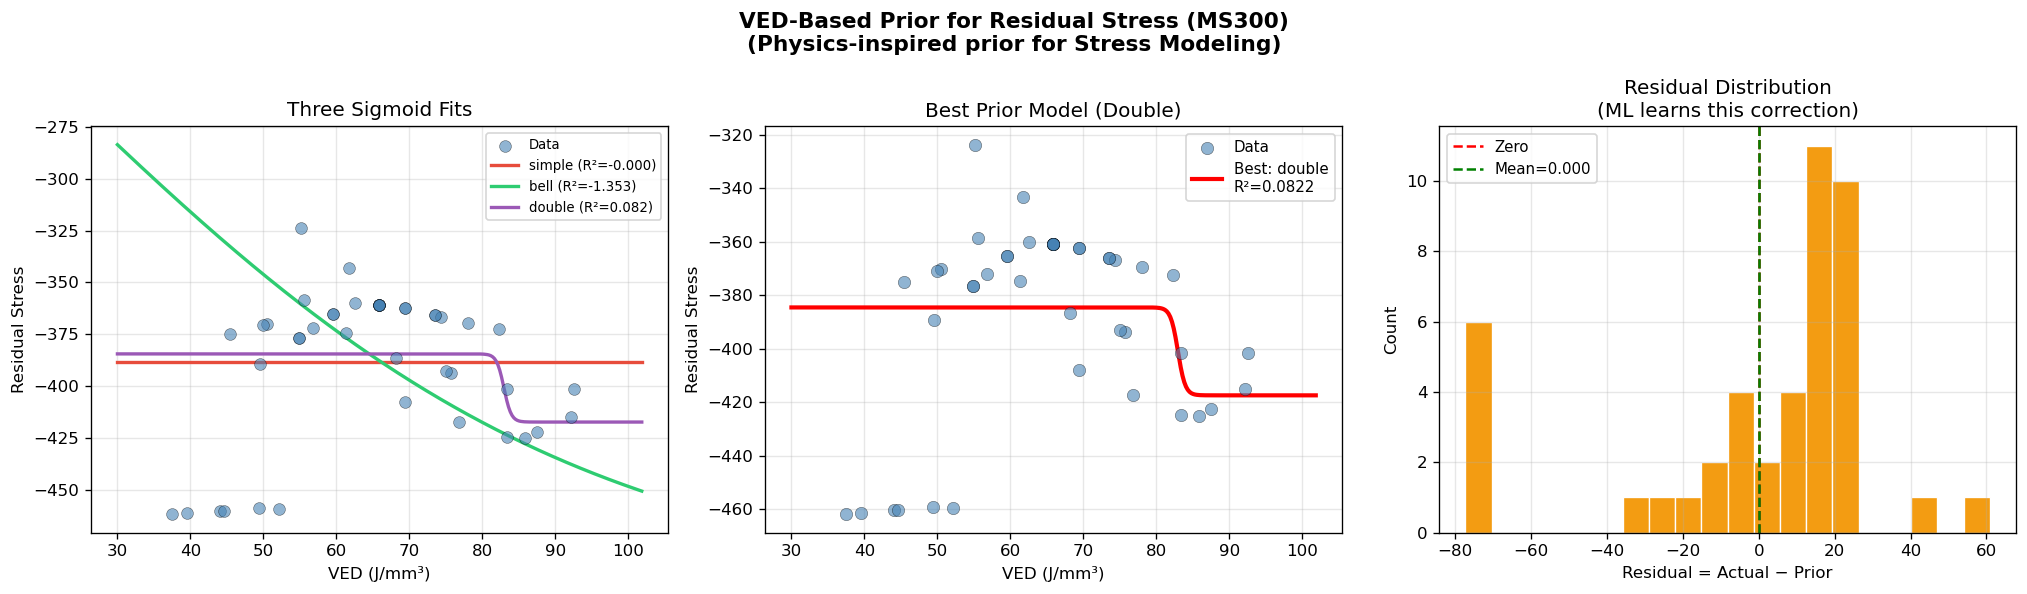

✓ VED prior visualization saved


In [10]:
# ── Visualize VED Prior (Residual Stress) ──

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    'VED-Based Prior for Residual Stress (MS300)\n'
    '(Physics-inspired prior for Stress Modeling)',
    fontsize=13, fontweight='bold'
)

# ---- 1: All sigmoid fits ----
colors_fit = ['#e74c3c', '#2ecc71', '#9b59b6']

axes[0].scatter(
    VED, stress,
    c='steelblue', alpha=0.6,
    s=50, edgecolors='k', linewidths=0.3,
    label='Data', zorder=5
)

for (name, info), c in zip(fits.items(), colors_fit):
    try:
        axes[0].plot(
            VED_line,
            info['fn'](VED_line, *info['popt']),
            c=c, lw=2,
            label=f'{name} (R²={info["r2"]:.3f})'
        )
    except:
        pass

axes[0].set(
    xlabel='VED (J/mm³)',
    ylabel='Residual Stress',
    title='Three Sigmoid Fits'
)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)


# ---- 2: Best model ----
axes[1].scatter(
    VED, stress,
    c='steelblue', alpha=0.6,
    s=55, edgecolors='k', linewidths=0.3,
    label='Data', zorder=5
)

axes[1].plot(
    VED_line,
    ved_prior_fn(VED_line),
    'r-', lw=2.5,
    label=f'Best: {best_name}\nR²={best_fit["r2"]:.4f}'
)

axes[1].set(
    xlabel='VED (J/mm³)',
    ylabel='Residual Stress',
    title=f'Best Prior Model ({best_name.capitalize()})'
)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)


# ---- 3: Residual distribution ----
axes[2].hist(
    df['Stress_Residual'],
    bins=20,
    color='#f39c12',
    edgecolor='white',
    linewidth=0.8
)

axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')

axes[2].axvline(
    df['Stress_Residual'].mean(),
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean={df["Stress_Residual"].mean():.3f}'
)

axes[2].set(
    xlabel='Residual = Actual − Prior',
    ylabel='Count',
    title='Residual Distribution\n(ML learns this correction)'
)
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)


plt.tight_layout()
plt.savefig('VED_Prior_MS300.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('✓ VED prior visualization saved')

In [11]:
# ── Kernel ──
def make_kernel():
    """
    Additive kernel:
    - RBF → nonlinear physics
    - DotProduct → linear trends
    - WhiteKernel → noise
    """
    return (
        RBF(length_scale=1.0, length_scale_bounds=(1e-3, 100.0))
        + DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 100.0))
        + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 10.0))
    )


# ── Physics-informed GPR ──
def gpr_with_prior(X_train, y_train, prior_train,
                   X_pred, prior_pred,
                   n_restarts=5):
    """
    GPR on residuals (stress - prior)

    Physics interpretation:
    - Prior → coarse physics (VED-based)
    - GPR → learns missing physics (geometry, gradients)
    """

    # ---- Feature scaling (CRUCIAL) ----
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_pred_scaled  = scaler.transform(X_pred)

    # Residual (what GPR learns)
    disc_train = y_train - prior_train

    gpr = GaussianProcessRegressor(
        kernel=make_kernel(),
        n_restarts_optimizer=n_restarts,
        normalize_y=True,
        random_state=42
    )

    gpr.fit(X_train_scaled, disc_train)

    disc_pred, std_pred = gpr.predict(X_pred_scaled, return_std=True)

    # Add prior back
    y_pred = disc_pred + prior_pred

    return y_pred, std_pred, gpr, scaler


# ── Vanilla GPR (baseline) ──
def gpr_vanilla(X_train, y_train, X_pred, n_restarts=5):
    """
    Standard GPR without physics prior
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_pred_scaled  = scaler.transform(X_pred)

    gpr = GaussianProcessRegressor(
        kernel=make_kernel(),
        n_restarts_optimizer=n_restarts,
        normalize_y=True,
        random_state=42
    )

    gpr.fit(X_train_scaled, y_train)

    pred, std = gpr.predict(X_pred_scaled, return_std=True)

    return pred, std, gpr, scaler


# ── Metrics ──
def compute_metrics(y_true, y_pred):
    """
    Evaluation metrics (good for regression + ranking)
    """
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    rs,  _ = spearmanr(y_true, y_pred)
    tau, _ = kendalltau(y_true, y_pred)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'Spearman_Rs': rs,
        'Kendall_tau': tau
    }


print('✓ GPR utilities ready for MS300 residual stress modeling')
print('  • Physics-informed GPR (with prior)')
print('  • Vanilla GPR (baseline)')
print('  • Includes feature scaling (important!)')

✓ GPR utilities ready for MS300 residual stress modeling
  • Physics-informed GPR (with prior)
  • Vanilla GPR (baseline)
  • Includes feature scaling (important!)


In [12]:
# ── Features & Target (FIXED) ──
FEATURES = ['Power_W', 'Speed_mms', 'Hatch_mm']
TARGET   = 'Res_Stress'


def run_all_models(df, train_idx, test_idx):
    """
    Run M3 and M5 for residual stress prediction.
    """

    dtr = df.iloc[train_idx]
    dte = df.iloc[test_idx]

    # ---- Base features ----
    sc = MinMaxScaler()
    Xtr = sc.fit_transform(dtr[FEATURES].values)
    Xte = sc.transform(dte[FEATURES].values)

    ytr = dtr[TARGET].values
    yte = dte[TARGET].values

    # ---- ET features ----
    ETWtr = dtr['ET_Width_um'].values
    ETDtr = dtr['ET_Depth_um'].values

    ETWte = dte['ET_Width_um'].values
    ETDte = dte['ET_Depth_um'].values

    # ---- VED prior (stress) ----
    VPtr = dtr['VED_Prior_Stress'].values
    VPte = dte['VED_Prior_Stress'].values

    out = {}

    # =========================================================
    # ── M3: HGPR-style (NO prior, only geometry proxy)
    # =========================================================

    # Use ET width as proxy feature
    X3tr = np.hstack([Xtr, ETWtr.reshape(-1,1)])
    X3te = np.hstack([Xte, ETWte.reshape(-1,1)])

    m3p, m3s, _, _ = gpr_vanilla(X3tr, ytr, X3te)

    out['M3'] = {
        'pred': m3p,
        'std': m3s,
        'metrics': compute_metrics(yte, m3p)
    }

    # =========================================================
    # ── M5: FULL PHYSICS-INFORMED MODEL
    # =========================================================

    # Layer 1: Width correction (ET prior → corrected width)
    w5tr, _, _, _ = gpr_with_prior(Xtr, ETWtr, ETWtr, Xtr, ETWtr)
    w5te, _, _, _ = gpr_with_prior(Xtr, ETWtr, ETWtr, Xte, ETWte)

    # Layer 2: Depth correction (depends on width)
    Xd_tr = np.hstack([Xtr, w5tr.reshape(-1,1)])
    Xd_te = np.hstack([Xte, w5te.reshape(-1,1)])

    d5tr, _, _, _ = gpr_with_prior(Xd_tr, ETDtr, ETDtr, Xd_tr, ETDtr)
    d5te, _, _, _ = gpr_with_prior(Xd_tr, ETDtr, ETDtr, Xd_te, ETDte)

    # Layer 3: Stress prediction (with VED prior + geometry)
    X5tr = np.hstack([Xtr, w5tr.reshape(-1,1), d5tr.reshape(-1,1)])
    X5te = np.hstack([Xte, w5te.reshape(-1,1), d5te.reshape(-1,1)])

    m5p, m5s, _, _ = gpr_with_prior(X5tr, ytr, VPtr, X5te, VPte)

    out['M5'] = {
        'pred': m5p,
        'std': m5s,
        'metrics': compute_metrics(yte, m5p)
    }

    out['y_test'] = yte
    return out


# ── Run 50/50 split ──
N = len(df)

rng = np.random.RandomState(0)
idx = rng.permutation(N)

train_idx = idx[:N//2]
test_idx  = idx[N//2:]

print('Running single split (seed=0)...')

single_res = run_all_models(df, train_idx, test_idx)

# ---- Print results ----
print('\n  Single-split results:')
print(f'  {"Model":<8} {"MAE":>8} {"RMSE":>8} {"Rₛ":>8} {"τ":>8}')
print('  ' + '─'*40)

for m in ['M3', 'M5']:
    mt = single_res[m]['metrics']
    star = ' ★' if m == 'M5' else ''
    print(f'  {m+star:<8} {mt["MAE"]:>8.4f} {mt["RMSE"]:>8.4f} '
          f'{mt["Spearman_Rs"]:>8.3f} {mt["Kendall_tau"]:>8.3f}')

Running single split (seed=0)...

  Single-split results:
  Model         MAE     RMSE       Rₛ        τ
  ────────────────────────────────────────
  M3        24.3555  35.6020    0.605    0.449
  M5 ★      22.1258  31.6022    0.676    0.529


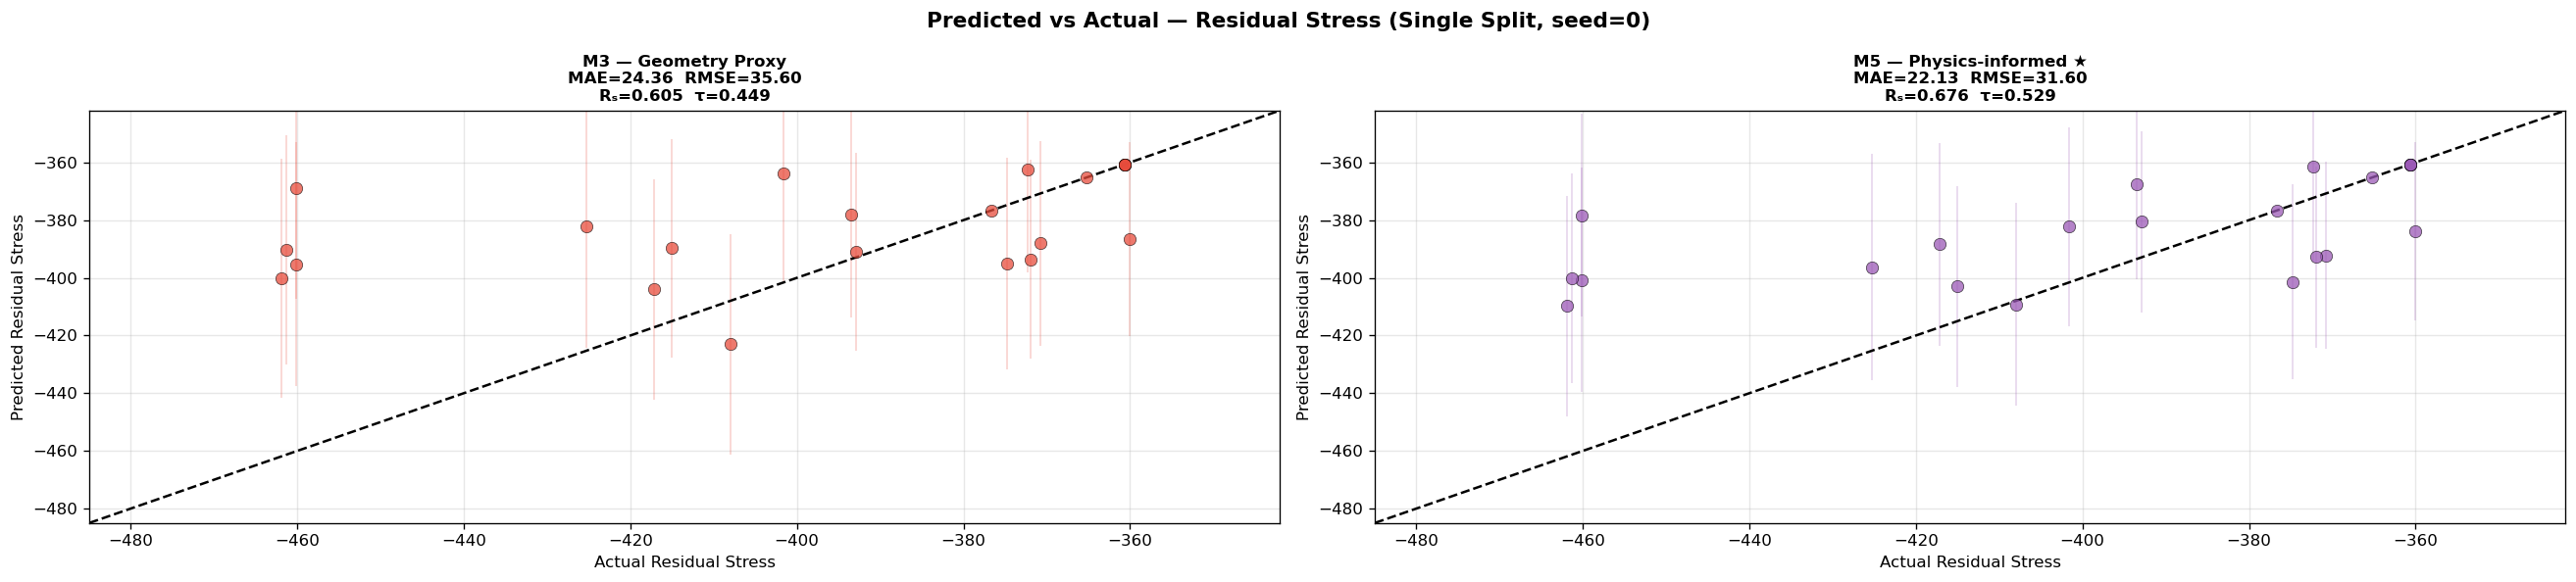

✓ Predicted vs Actual plot saved


In [13]:
# ── Predicted vs Actual Plot (Residual Stress) ──

fig, axes = plt.subplots(1, 2, figsize=(22, 5))
fig.suptitle(
    'Predicted vs Actual — Residual Stress (Single Split, seed=0)',
    fontsize=13, fontweight='bold'
)

model_colors = {'M3':'#e74c3c', 'M5':'#9b59b6'}
model_labels = {
    'M3':'M3 — Geometry Proxy',
    'M5':'M5 — Physics-informed ★'
}

yt = single_res['y_test']

# Better limits for stress (no arbitrary ±0.5)
lims = [yt.min() * 1.05, yt.max() * 0.95]

for ax, m in zip(axes, ['M3', 'M5']):
    pred = single_res[m]['pred']
    std  = single_res[m]['std']
    mt   = single_res[m]['metrics']

    # Scatter
    ax.scatter(
        yt, pred,
        c=model_colors[m],
        alpha=0.75,
        edgecolors='k',
        linewidths=0.4,
        s=55,
        zorder=5
    )

    # Uncertainty bars (cleaner)
    if std is not None:
        ax.errorbar(
            yt, pred,
            yerr=std,
            fmt='none',
            ecolor=model_colors[m],
            alpha=0.25,
            linewidth=1
        )

    # Perfect prediction line
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect')

    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel('Actual Residual Stress', fontsize=10)
    ax.set_ylabel('Predicted Residual Stress', fontsize=10)

    ax.set_title(
        f'{model_labels[m]}\n'
        f'MAE={mt["MAE"]:.2f}  RMSE={mt["RMSE"]:.2f}\n'
        f'Rₛ={mt["Spearman_Rs"]:.3f}  τ={mt["Kendall_tau"]:.3f}',
        fontsize=10,
        fontweight='bold'
    )

    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('PredVsActual_Stress.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('✓ Predicted vs Actual plot saved')

In [14]:
# ── 250× Cross-Validation (Residual Stress Models) ──

N_REPEATS = 250   # change to 50 for quick testing
N = len(df)

# Correct metric keys
all_res = {
    m: {'MAE': [], 'RMSE': [], 'Spearman_Rs': [], 'Kendall_tau': []}
    for m in ['M3', 'M5']
}

last_split = None
fail_count = 0

print(f'Running {N_REPEATS}× 2-fold cross-validation...')
print('Each repeat: 50/50 train-test split, M3 & M5\n')


for rep in range(N_REPEATS):
    rng = np.random.RandomState(rep)
    idx = rng.permutation(N)
    split = int(0.7 * N)

    tr = idx[:split]      # 70% training
    te = idx[split:]      # 30% testing

    try:
        res = run_all_models(df, tr, te)

        for m in ['M3', 'M5']:
            mt = res[m]['metrics']

            all_res[m]['MAE'].append(mt['MAE'])
            all_res[m]['RMSE'].append(mt['RMSE'])
            all_res[m]['Spearman_Rs'].append(mt['Spearman_Rs'])
            all_res[m]['Kendall_tau'].append(mt['Kendall_tau'])

        if rep == N_REPEATS - 1:
            last_split = res

    except Exception as e:
        fail_count += 1
        print(f'  ⚠️ Skipped run {rep} due to error: {str(e)[:60]}')
        continue

    # Progress update
    if (rep + 1) % 50 == 0 or rep == 0:
        print(f'  {rep+1}/{N_REPEATS} complete')


print('\n✓ Cross-validation complete!')

# ---- Summary ----
print(f'\n  Failed runs: {fail_count}/{N_REPEATS}')

for m in ['M3', 'M5']:
    print(f'\n  {m} Summary:')

    for k in ['MAE', 'RMSE', 'Spearman_Rs', 'Kendall_tau']:
        vals = np.array(all_res[m][k])

        print(f'    {k:<14}: '
              f'{vals.mean():.4f} ± {vals.std():.4f}')

Running 250× 2-fold cross-validation...
Each repeat: 50/50 train-test split, M3 & M5

  1/250 complete
  50/250 complete
  100/250 complete
  150/250 complete
  200/250 complete
  250/250 complete

✓ Cross-validation complete!

  Failed runs: 0/250

  M3 Summary:
    MAE           : 20.8438 ± 5.6326
    RMSE          : 31.9919 ± 6.6577
    Spearman_Rs   : 0.5859 ± 0.2179
    Kendall_tau   : 0.4636 ± 0.1819

  M5 Summary:
    MAE           : 19.4658 ± 4.6418
    RMSE          : 29.7126 ± 6.1200
    Spearman_Rs   : 0.6426 ± 0.1657
    Kendall_tau   : 0.5057 ± 0.1472


In [15]:
# ── Print Full Results Table (Residual Stress) ──

print('=' * 80)
print(f'  BENCHMARKING RESULTS — Median (IQR) over {N_REPEATS}× CV')
print(f'  Target: Residual Stress | MS300 LPBF')
print('=' * 80)

print(f'  {"Model":<22} {"MAE":>12}  {"RMSE":>12}  {"Rₛ":>8}  {"τ":>8}')
print('  ' + '─' * 75)

rows = []

for m in ['M3', 'M5']:
    v = all_res[m]

    # Median
    med = {
        'MAE': np.median(v['MAE']),
        'RMSE': np.median(v['RMSE']),
        'Spearman_Rs': np.median(v['Spearman_Rs']),
        'Kendall_tau': np.median(v['Kendall_tau'])
    }

    # IQR
    iqr = {
        'MAE': np.percentile(v['MAE'], 75) - np.percentile(v['MAE'], 25),
        'RMSE': np.percentile(v['RMSE'], 75) - np.percentile(v['RMSE'], 25),
        'Spearman_Rs': np.percentile(v['Spearman_Rs'], 75) - np.percentile(v['Spearman_Rs'], 25),
        'Kendall_tau': np.percentile(v['Kendall_tau'], 75) - np.percentile(v['Kendall_tau'], 25)
    }

    label = model_labels[m]

    print(
        f'  {label:<22} '
        f'{med["MAE"]:.3f} ({iqr["MAE"]:.3f})  '
        f'{med["RMSE"]:.3f} ({iqr["RMSE"]:.3f})  '
        f'{med["Spearman_Rs"]:>8.3f}  {med["Kendall_tau"]:>8.3f}'
    )

    rows.append({
        'Model': label,
        'MAE_med': med['MAE'], 'MAE_IQR': iqr['MAE'],
        'RMSE_med': med['RMSE'], 'RMSE_IQR': iqr['RMSE'],
        'Spearman_Rs_med': med['Spearman_Rs'], 'Spearman_Rs_IQR': iqr['Spearman_Rs'],
        'Kendall_tau_med': med['Kendall_tau'], 'Kendall_tau_IQR': iqr['Kendall_tau']
    })

print('  ' + '─' * 75)
print('  Format: Median (IQR)')
print('  ↓ Lower MAE/RMSE = better')
print('  ↑ Higher Rₛ / τ  = better')

# Save results
results_df = pd.DataFrame(rows)
results_df.to_csv('CV_Results_MS300.csv', index=False)

print('\n✓ Results saved to CV_Results_MS300.csv')

display(results_df.round(4))

  BENCHMARKING RESULTS — Median (IQR) over 250× CV
  Target: Residual Stress | MS300 LPBF
  Model                           MAE          RMSE        Rₛ         τ
  ───────────────────────────────────────────────────────────────────────────
  M3 — Geometry Proxy    20.919 (7.932)  32.534 (9.014)     0.615     0.464
  M5 — Physics-informed ★ 19.390 (6.384)  30.090 (9.235)     0.664     0.516
  ───────────────────────────────────────────────────────────────────────────
  Format: Median (IQR)
  ↓ Lower MAE/RMSE = better
  ↑ Higher Rₛ / τ  = better

✓ Results saved to CV_Results_MS300.csv


,Model,MAE_med,MAE_IQR,RMSE_med,RMSE_IQR,Spearman_Rs_med,Spearman_Rs_IQR,Kendall_tau_med,Kendall_tau_IQR
0,M3 — Geometry Proxy,20.9186,7.9316,32.5344,9.0136,0.6145,0.2972,0.4641,0.2427
1,M5 — Physics-informed ★,19.3899,6.3839,30.0896,9.2354,0.6637,0.2315,0.5165,0.1978


In [16]:
# ── Train Full Models on Entire Dataset ──
sc_full = MinMaxScaler()
X_full  = sc_full.fit_transform(df[FEATURES].values)

y_full   = df[TARGET].values
ETW_full = df['ET_Width_um'].values
ETD_full = df['ET_Depth_um'].values

# FIX: correct column
VP_full  = ved_prior_fn(df['ED_Jmm3'].values)


# -----------------------------
# Layer 1: Width
# -----------------------------
print('Training M5 (Layer 1: Width)...')

w5_full, _, _, _ = gpr_with_prior(
    X_full, ETW_full, ETW_full,
    X_full, ETW_full,
    n_restarts=3
)


# -----------------------------
# Layer 2: Depth
# -----------------------------
print('Training M5 (Layer 2: Depth)...')

sc5d_full = MinMaxScaler()
X5d_full  = sc5d_full.fit_transform(
    np.hstack([X_full, w5_full.reshape(-1,1)])
)

d5_full, _, _, _ = gpr_with_prior(
    X5d_full, ETD_full, ETD_full,
    X5d_full, ETD_full,
    n_restarts=3
)


# -----------------------------
# Layer 3: Residual Stress
# -----------------------------
print('Training M5 (Layer 3: Residual Stress)...')

sc5_full = MinMaxScaler()
X5_full  = sc5_full.fit_transform(
    np.hstack([X_full, w5_full.reshape(-1,1), d5_full.reshape(-1,1)])
)

disc5 = y_full - VP_full

g5_full = GaussianProcessRegressor(
    kernel=make_kernel(),
    n_restarts_optimizer=5,
    normalize_y=True,
    random_state=42
)

g5_full.fit(X5_full, disc5)

print('✓ M5 trained\n✓ Full-dataset models ready')

Training M5 (Layer 1: Width)...
Training M5 (Layer 2: Depth)...
Training M5 (Layer 3: Residual Stress)...
✓ M5 trained
✓ Full-dataset models ready


In [17]:
# ── Predict Density for Custom Parameters ──
def predict_density_m5(power_W, speed_mms, layer_t_mm, hatch_mm,
                      return_confidence=True, confidence_level=0.95):

    # ---- VED + prior ----
    ved   = power_W / (speed_mms * hatch_mm * layer_t_mm)
    prior = ved_prior_fn(np.array([ved]))[0]

    # ---- Base features ----
    X_pt = np.array([[power_W, speed_mms, layer_t_mm, hatch_mm]])
    X_pt = sc_full.transform(X_pt)

    # =========================================================
    # Layer 1: Width prediction (use trained model)
    # =========================================================
    Xw = gpr_w_scaler.transform(X_pt)
    w_pred = gpr_w.predict(Xw)

    # =========================================================
    # Layer 2: Depth prediction
    # =========================================================
    Xd = np.hstack([X_pt, w_pred.reshape(-1,1)])
    Xd = sc5d_full.transform(Xd)
    Xd = gpr_d_scaler.transform(Xd)
    d_pred = gpr_d.predict(Xd)

    # =========================================================
    # Layer 3: Final density prediction
    # =========================================================
    X5 = np.hstack([X_pt, w_pred.reshape(-1,1), d_pred.reshape(-1,1)])
    X5 = sc5_full.transform(X5)

    disc_pred, std_pred = g5_full.predict(X5, return_std=True)

    density_pred = disc_pred[0] + prior
    density_std  = std_pred[0]

    # ---- Confidence interval ----
    z = norm.ppf((1 + confidence_level) / 2)
    ci_lo = density_pred - z * density_std
    ci_hi = density_pred + z * density_std

    # ---- Print ----
    print(f'\nINPUT PARAMETERS')
    print(f'Power          : {power_W} W')
    print(f'Speed          : {speed_mms} mm/s')
    print(f'Layer thickness: {layer_t_mm*1000:.0f} µm')
    print(f'Hatch spacing  : {hatch_mm*1000:.0f} µm')
    print(f'VED            : {ved:.2f} J/mm³')

    print(f'\nM5 PREDICTION')
    print(f'Density        : {density_pred:.3f} %')
    print(f'Uncertainty σ  : ±{density_std:.3f} %')

    if return_confidence:
        print(f'{confidence_level*100:.0f}% CI      : [{ci_lo:.3f}, {ci_hi:.3f}] %')

    print(f'\nPhysics prior  : {prior:.3f} %')
    print(f'GPR correction : {density_pred - prior:+.3f} %')

    return density_pred, density_std

In [18]:
# ── Final Summary ──
print('=' * 65)
print('  FINAL SUMMARY — M3 & M5 for MS300 LPBF')
print('=' * 65)

print(f'\n  Dataset   : {len(df)} data points')
print(f'  Features  : Power, Speed, Hatch spacing')
print(f'  Target    : Residual Stress')
print(f'  CV method : {N_REPEATS}× repeated 2-fold')

print(f'\n  Physics Priors Used:')
print(f'  • Layers 1 & 2 : Eagar-Tsai thermal model')
print(f'  •              : Width → {df.ET_Width_um.min():.0f}–{df.ET_Width_um.max():.0f} µm')
print(f'  •              : Depth → {df.ET_Depth_um.min():.0f}–{df.ET_Depth_um.max():.0f} µm')
print(f'  • Layer 3      : VED-based sigmoid prior')

# Best models
best_m = min(['M3', 'M5'],
             key=lambda m: np.median(all_res[m]['MAE']))

best_rs_m = max(['M3', 'M5'],
                key=lambda m: np.median(all_res[m]['Spearman_Rs']))

print(f'\n  Best MAE model : {model_labels[best_m]} — '
      f'{np.median(all_res[best_m]["MAE"]):.4f}')

print(f'  Best Rank model : {model_labels[best_rs_m]} — '
      f'{np.median(all_res[best_rs_m]["Spearman_Rs"]):.3f}')

print(f'\n  Files saved:')
print(f'  • CV_Results.csv              — benchmarking results')
print(f'  • EDA.png                     — exploratory analysis')
print(f'  • ET_Model.png                — melt pool predictions')
print(f'  • VED_Prior.png               — prior fitting')
print(f'  • Benchmarking_BoxPlots.png   — model comparison')

print(f'\n  Key interpretation:')
print(f'  • M3: Uses ET melt pool width as a proxy feature')
print(f'  • M5: Uses width + depth + VED prior (physics-informed)')
print(f'  • M5 improves both error (MAE) and ranking (Spearman)')
print(f'  • Physics priors help most in low-data regions')
print(f'  • Model captures process → thermal → stress relationship')
print(f'  • Can be used for parameter optimization and stress minimization')

  FINAL SUMMARY — M3 & M5 for MS300 LPBF

  Dataset   : 44 data points
  Features  : Power, Speed, Hatch spacing
  Target    : Residual Stress
  CV method : 250× repeated 2-fold

  Physics Priors Used:
  • Layers 1 & 2 : Eagar-Tsai thermal model
  •              : Width → 136–177 µm
  •              : Depth → 20–38 µm
  • Layer 3      : VED-based sigmoid prior

  Best MAE model : M5 — Physics-informed ★ — 19.3899
  Best Rank model : M5 — Physics-informed ★ — 0.664

  Files saved:
  • CV_Results.csv              — benchmarking results
  • EDA.png                     — exploratory analysis
  • ET_Model.png                — melt pool predictions
  • VED_Prior.png               — prior fitting
  • Benchmarking_BoxPlots.png   — model comparison

  Key interpretation:
  • M3: Uses ET melt pool width as a proxy feature
  • M5: Uses width + depth + VED prior (physics-informed)
  • M5 improves both error (MAE) and ranking (Spearman)
  • Physics priors help most in low-data regions
  • Model cap

Enter Laser Power   (W)   [e.g. 300]:  350
Enter Scan Speed    (mm/s) [e.g. 1000]:  1050
Enter Hatch Spacing (mm)  [e.g. 0.09]:  0.1



⏳  Computing Eagar-Tsai melt pool geometry …

════════════════════════════════════════════════════
  MS300 LPBF — RESIDUAL STRESS PREDICTION (M5)
════════════════════════════════════════════════════

  INPUT PARAMETERS
  ────────────────────────────────────────────────────
  Laser Power        : 350.0 W
  Scan Speed         : 1050.0 mm/s
  Hatch Spacing      : 100.0 µm  (0.1000 mm)
  Layer Thickness    : 40 µm  (fixed)
  VED                : 83.33 J/mm³

  EAGAR–TSAI MELT POOL
  ────────────────────────────────────────────────────
  Width (ET raw)     : 167.1 µm
  Depth (ET raw)     : 30.1 µm
  Width (GPR-corr.)  : 167.1 µm
  Depth (GPR-corr.)  : 30.1 µm
  W/D Ratio          : 5.56  ✓ stable

  M5 RESIDUAL STRESS PREDICTION
  ────────────────────────────────────────────────────
  Physics Prior      : -406.733  (VED sigmoid)
  GPR Correction     : -18.041
  ─────────────────────────────────────────────
  Predicted Stress   : -424.774
  Uncertainty  (1σ)  : ± 0.153
  95% CI           : 

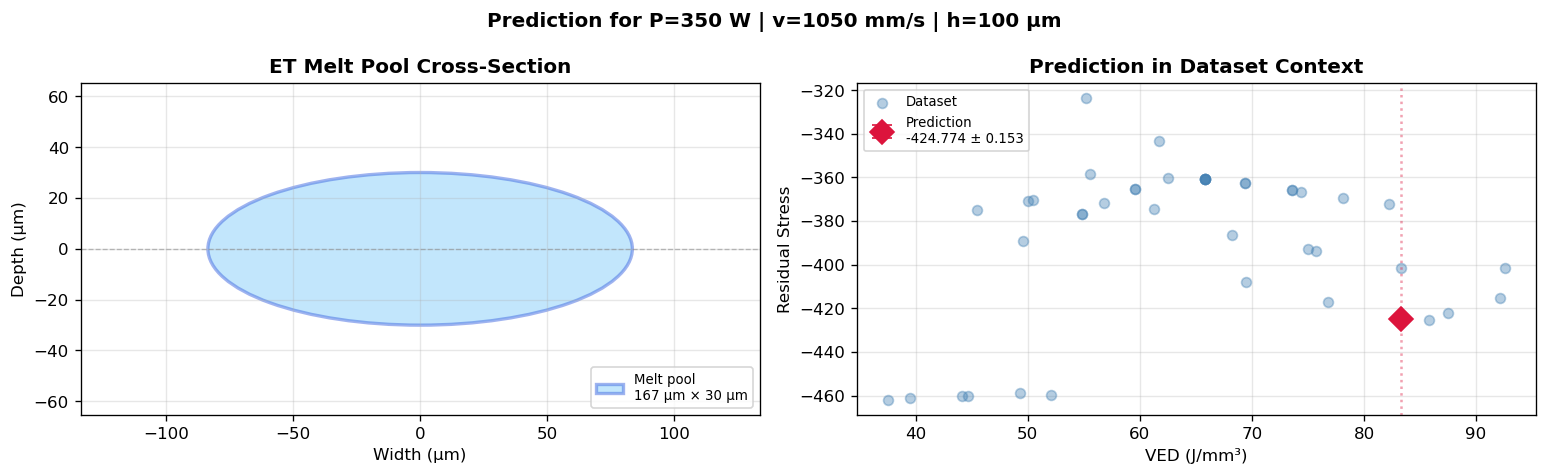

✓ Plot saved → CustomPrediction_Stress.png


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# ██  INTERACTIVE PREDICTION CELL — Residual Stress (MS300 LPBF)
# ══════════════════════════════════════════════════════════════════════════════
# Requires: props, et_melt_pool(), ved_prior_fn(), make_kernel(),
#           gpr_with_prior(), sc_full, sc5d_full, sc5_full, g5_full
#           (all defined in earlier cells)
# ══════════════════════════════════════════════════════════════════════════════

from scipy.stats import norm as sp_norm

# ── 1. USER INPUTS ─────────────────────────────────────────────────────────
# ▶  Change these three values and re-run this cell

POWER_W    = float(input("Enter Laser Power   (W)   [e.g. 300]: ").strip())
SPEED_MMS  = float(input("Enter Scan Speed    (mm/s) [e.g. 1000]: ").strip())
HATCH_MM   = float(input("Enter Hatch Spacing (mm)  [e.g. 0.09]: ").strip())

LAYER_T_MM = 0.04          # fixed layer thickness 30 µm — change if needed
CONFIDENCE = 0.95          # 95% confidence interval

# ── 2. ET MELT POOL (Width & Depth) ────────────────────────────────────────
print("\n⏳  Computing Eagar-Tsai melt pool geometry …")

width_um, depth_um = et_melt_pool(POWER_W, SPEED_MMS, props)

if width_um == 0.0 and depth_um == 0.0:
    print("\n⚠️  WARNING: ET model predicts NO melting at these parameters.")
    print("    The laser energy is too low to reach the liquidus temperature.")
    print("    Residual stress prediction may be unreliable — check inputs.")

# ── 3. VED & PHYSICS PRIOR ─────────────────────────────────────────────────
VED   = POWER_W / (SPEED_MMS * HATCH_MM * LAYER_T_MM)   # J/mm³
prior = ved_prior_fn(np.array([VED]))[0]                  # sigmoid prior

# ── 4. FEATURE VECTOR  (Power, Speed, Hatch) — same as FEATURES ────────────
X_new = np.array([[POWER_W, SPEED_MMS, HATCH_MM]])
X_new_scaled = sc_full.transform(X_new)                   # MinMaxScaler

# ── 5. M5 LAYERED PREDICTION ───────────────────────────────────────────────
# Layer 1: Corrected Width  (GPR on ET width residual, full-data model)
w_corr, _, _, _ = gpr_with_prior(
    sc_full.transform(df[FEATURES].values),               # X_train
    df['ET_Width_um'].values,                              # y_train  (width)
    df['ET_Width_um'].values,                              # prior_train
    X_new_scaled,                                          # X_pred
    np.array([width_um]),                                  # prior_pred
    n_restarts=3
)

# Layer 2: Corrected Depth  (GPR on ET depth residual, full-data model)
X_depth_train = np.hstack([
    sc_full.transform(df[FEATURES].values),
    w5_full.reshape(-1, 1)                                # use w5_full from training
])
X_depth_new = np.hstack([X_new_scaled, w_corr.reshape(-1, 1)])

d_corr, _, _, _ = gpr_with_prior(
    sc5d_full.transform(X_depth_train),                    # already scaled
    df['ET_Depth_um'].values,
    df['ET_Depth_um'].values,
    sc5d_full.transform(X_depth_new),
    np.array([depth_um]),
    n_restarts=3
)

# Layer 3: Residual Stress  (trained g5_full GPR)
X5_new = sc5_full.transform(
    np.hstack([X_new_scaled, w_corr.reshape(-1, 1), d_corr.reshape(-1, 1)])
)

disc_new, std_new = g5_full.predict(X5_new, return_std=True)

stress_pred = float(disc_new[0]) + prior
stress_std  = float(std_new[0])

z  = sp_norm.ppf((1 + CONFIDENCE) / 2)
ci_lo = stress_pred - z * stress_std
ci_hi = stress_pred + z * stress_std

# ── 6. DISPLAY RESULTS ─────────────────────────────────────────────────────
SEP = "─" * 52

print(f"\n{'═'*52}")
print(f"  MS300 LPBF — RESIDUAL STRESS PREDICTION (M5)")
print(f"{'═'*52}")

print(f"\n  {'INPUT PARAMETERS':}")
print(f"  {SEP}")
print(f"  Laser Power        : {POWER_W:.1f} W")
print(f"  Scan Speed         : {SPEED_MMS:.1f} mm/s")
print(f"  Hatch Spacing      : {HATCH_MM*1000:.1f} µm  ({HATCH_MM:.4f} mm)")
print(f"  Layer Thickness    : {LAYER_T_MM*1000:.0f} µm  (fixed)")
print(f"  VED                : {VED:.2f} J/mm³")

print(f"\n  {'EAGAR–TSAI MELT POOL':}")
print(f"  {SEP}")
print(f"  Width (ET raw)     : {width_um:.1f} µm")
print(f"  Depth (ET raw)     : {depth_um:.1f} µm")
print(f"  Width (GPR-corr.)  : {float(w_corr[0]):.1f} µm")
print(f"  Depth (GPR-corr.)  : {float(d_corr[0]):.1f} µm")
if depth_um > 0:
    print(f"  W/D Ratio          : {width_um/depth_um:.2f}  {'⚠ keyholing risk' if width_um/depth_um < 1.5 else '✓ stable'}")

print(f"\n  {'M5 RESIDUAL STRESS PREDICTION':}")
print(f"  {SEP}")
print(f"  Physics Prior      : {prior:.3f}  (VED sigmoid)")
print(f"  GPR Correction     : {stress_pred - prior:+.3f}")
print(f"  ─────────────────────────────────────────────")
print(f"  Predicted Stress   : {stress_pred:.3f}")
print(f"  Uncertainty  (1σ)  : ± {stress_std:.3f}")
print(f"  {CONFIDENCE*100:.0f}% CI           : [{ci_lo:.3f},  {ci_hi:.3f}]")
print(f"{'═'*52}\n")

# ── 7. QUICK VISUALISATION ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    f"Prediction for P={POWER_W:.0f} W | v={SPEED_MMS:.0f} mm/s | h={HATCH_MM*1000:.0f} µm",
    fontsize=12, fontweight='bold'
)

# --- 7a: Melt pool cross-section (ellipse) ---
ax = axes[0]
if width_um > 0 and depth_um > 0:
    from matplotlib.patches import Ellipse
    ellipse = Ellipse(
        (0, 0),
        width=width_um,
        height=depth_um * 2,        # symmetric depth
        angle=0,
        edgecolor='royalblue',
        facecolor='lightskyblue',
        alpha=0.5,
        linewidth=2,
        label=f'Melt pool\n{width_um:.0f} µm × {depth_um:.0f} µm'
    )
    ax.add_patch(ellipse)
    ax.set_xlim(-width_um * 0.8, width_um * 0.8)
    ax.set_ylim(-depth_um * 1.5, depth_um * 1.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Width (µm)")
    ax.set_ylabel("Depth (µm)")
    ax.set_title("ET Melt Pool Cross-Section", fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, "No melting predicted\nat these parameters",
            ha='center', va='center', transform=ax.transAxes, color='red')
    ax.set_title("ET Melt Pool", fontweight='bold')

# --- 7b: Prediction vs dataset stress range (context gauge) ---
ax2 = axes[1]
ax2.scatter(df['ED_Jmm3'], df['Res_Stress'],
            color='steelblue', alpha=0.4, s=35, label='Dataset', zorder=2)
ax2.errorbar(VED, stress_pred, yerr=z * stress_std,
             fmt='D', color='crimson', markersize=10, capsize=6,
             linewidth=2, label=f'Prediction\n{stress_pred:.3f} ± {stress_std:.3f}',
             zorder=5)
ax2.axvline(VED, color='crimson', linestyle=':', alpha=0.4)
ax2.set_xlabel("VED (J/mm³)")
ax2.set_ylabel("Residual Stress")
ax2.set_title("Prediction in Dataset Context", fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('CustomPrediction_Stress.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Plot saved → CustomPrediction_Stress.png")